#**Goal**: ⭐️To get our model to perdict whether our review is a positive or negative one, using patterns in language⭐️


# **1.Load and Explore**

(Shapes, dtypes, missing values, Plot rating distibution, class balace)


The Nessicary Libraries

---



In [44]:
import pandas as pd #dataset orgnaziation library
import numpy as np #scientific starndard for arrays, to manipulate

#make accesible from google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:

path = "/content/drive/MyDrive/IMDB_Data/IMDB_Dataset.csv"
df = pd.read_csv(path)

#Visualize the data
#df_shape = rows,columns
print(f"Shape: {df.shape} ({df.shape[0]:,} reviews, and {df.shape[1]} columns)")
print(f"\n Column Names: {df.columns}") #converts from pandas dataframe 'object data type' to python list
print(f"\n Data types: \n {df.dtypes}") # ints, floats, char, strs

df.head()

Shape: (50000, 2) (50,000 reviews, and 2 columns)

 Column Names: Index(['review', 'sentiment'], dtype='object')

 Data types: 
 review       object
sentiment    object
dtype: object


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [46]:
# Getting rid of nulls
print(f"Missing Values: {df.isnull().sum()}")

Missing Values: review       0
sentiment    0
dtype: int64


In [47]:
#sentiment distribution
print(f"Sentiment Distribtion:")
print(df['sentiment'].value_counts())

#even distribution of percentage of each category
print(f'\nClass Balance:{df["sentiment"].value_counts(normalize=True).to_dict()}')
#round(3) = round to 3 decimals

Sentiment Distribtion:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Class Balance:{'positive': 0.5, 'negative': 0.5}


**Visualization of Raw Data**

In [48]:
#Important Libraries
import matplotlib.pyplot as plt # to graph and plot the data
import seaborn as sns #Also a graphing library, for heatplots, etc...


In [49]:

#Adding another column to see the legnth of each review, their crazy long some of them 🫠
#lamda calc,
#split() takes "I love this song" - > ['I', 'love', 'this', 'song']
df['review_legnth'] = df['review'].apply(lambda x: len(x.split()))


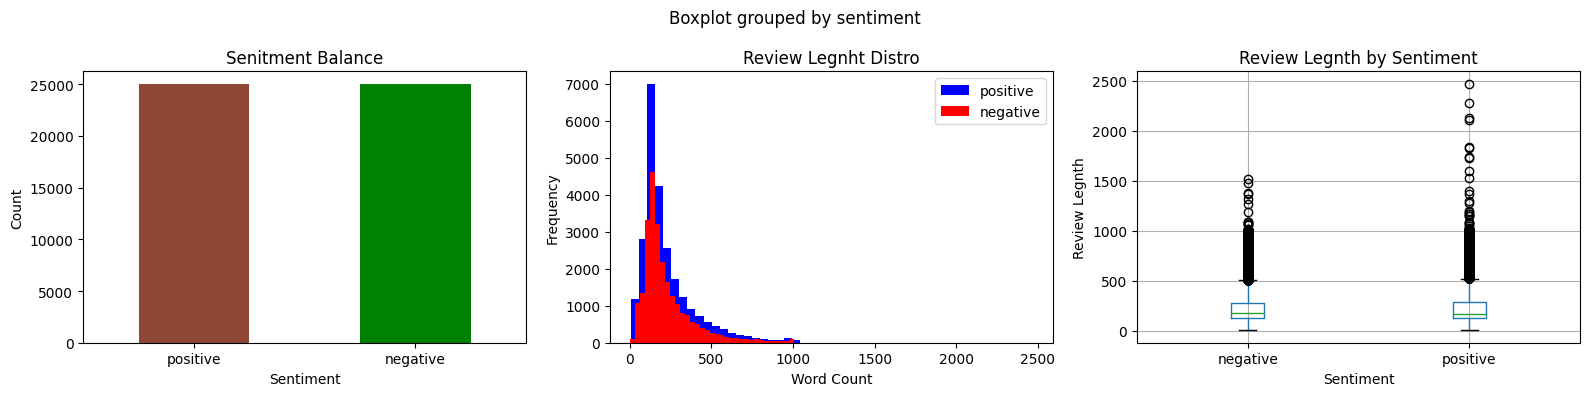

In [50]:
import matplotlib.pyplot as plt # to graph and plot the data
import seaborn as sns #Also a graphing library, for heatplots, etc...

#subplots(rows, columns, figsize = (w,h in inches))
#subplots is just organization to show multiple plots per figure
fig, axes = plt.subplots(1,3,figsize=(16,4))
fig.suptitle('Dataset Overview')

#Sentiment Distro
colors = ['#8f4735', 'green']
df['sentiment'].value_counts().plot(
    kind='bar',ax=axes[0], color=colors)
axes[0].set_title("Senitment Balance")
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

#Review Legnth
df[df['sentiment'] == 'positive']['review_length'].plot(
    kind='hist',ax=axes[1], bins=50, color="blue", label = 'positive')

df[df['sentiment'] == 'negative']['review_length'].plot(
    kind='hist',ax=axes[1], bins=50, color="red", label = 'negative')
axes[1].set_title("Review Lenght Distro")
axes[1].set_xlabel("Word Count")
axes[1].legend()

df.boxplot(column = 'review_length', by='sentiment', ax=axes[2])
axes[2].set_title("Review Length by Sentiment")
axes[2].set_xlabel("Sentiment")
axes[2].set_ylabel("Review Length")

plt.tight_layout() # fixing overall layout
plt.show()


**Real Reviews**

In [51]:
#Positive review, example review
#.sample() is specific to dataframes, grabbing random
for review in df[df['sentiment'] == 'positive']['review'].sample(2):
  print(f'    "{review}"')
  print()

    "The DVD jacket in which this movie came describes it as "uplifting and humorous." Those are not the words I would have chosen - not by a long shot. I would choose a word like "sombre," sometimes even "depressing." Which isn't to say that it's a bad movie. It's actually a pretty good movie, featuring good performances from the leads, with enough uncertainty throughout about what's going to happen at the end that you keep watching. The uncertainty comes from the structure of the movie - it seems to revolve around Ellen's reminiscences of her mother's slow death from cancer, as she is interviewed by the DA. So, we know from the start that something suspicious happened at the end - the questions are "what?" and "who?" <br /><br />Renee Zellweger was very good as Ellen - the somewhat resentful daughter who has to give up her life and job in New York to return home to care for her sick mother. Ellen evolves through the movie - moreso than any other character - as she learns to deal with

#**2.Preprocess Text**

(Lowercases, remove punctuation, tokenize, remove stopwords, lemmatize)

Need to normalize / clean text itself before feeding it into a ML model

Nessicary Libraries

---

In [52]:
import nltk #natrual langauge tool kit, for tokenization, stopwords, normalizing words,tagging, etc...
#has its limimitations, for larger datasets, spaCy is better
from nltk.corpus import stopwords # "the", "is", "a", dropping = non-important
from nltk.tokenize import word_tokenize # "Hello there!" - > ["Hello", "There"]
from nltk.stem import WordNetLemmatizer # Base Form: "Running" ->. "Run"

#NLTK is a toolset, you need to download all the tools
nltk.download('punkt', quiet=True) # the quiet just means dont print to console once your down downloading
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

import re #to manipulte text

**Stopwords / Lemmantizer**

In [53]:
#stopwords.words('english') = sets the english list of stopwords
#set() converts into python list
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer() #initialize the lemmatizer


def preprocess_text(text):
  #.isna(). -> bool
  if pd.isna(text):
    return ''

  #text manipulation part

  #Step1: Remove HTML Tags

  #re demo, regex(regular expression) = .*?
  # . = match any character, with anything
  #  *  = repeat the previous thing until > is found
  # ? = lazy evaluation, STOP at the next > and do not read another <

  #.sub()  = subsitute

  text = re.sub(r'<.*?>', '', text)

  #Step2: make lowercase
  text = text.lower()

  #Step 3: Keep only letter and spaces
  # ^ = match anything not in this list
  #a-z = any lowercase letter
  #\s = any whitespace character
  #gets rid of any numbers, punctiations, symbols, uppercase
  text = re.sub(r'[^a-z\s]', '', text)

  #Step 4: Tokenize
  #"I love you" -> ["I", "love", "you"]
  tokens = word_tokenize(text)

  #Step 5: Remove stop words
  #only grabbing non stop words, and len(t) > 2, removes words like "it", etc...
  tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

  #Step 6: lemmatize
  #base forms: "loving" -> "love"
  tokens = [lemmatizer.lemmatize(t) for t in tokens]

  #step 7: rejoin
  #adds a space in between the list and combines into one string
  return ' '.join(tokens)



**DEMO to see how it worked!!**

In [54]:
raw = df['review'].iloc[0]
#iloc = integer location to index in dataframe
raw_clean = preprocess_text(raw)

print(f"BEFORE: {raw[:400]}")
print(f"AFTER: {raw_clean[:400]}")

BEFORE: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to
AFTER: one reviewer mentioned watching episode youll hooked right exactly happened methe first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards


**Apply to full dataset**

In [58]:
#Create a new column for cleaned reviews
df['clean_reviews'] = df['review'].apply(preprocess_text)


,review,clean_reviews,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching episode youll ...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


In [59]:
#Verify it worked
df[['review', 'clean_reviews', 'sentiment']].head(5)

,review,clean_reviews,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching episode youll ...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


**Word Clouds**

(most common words based off sentiment, pos or neg)


In [61]:
#The correct library
from wordcloud import WordCloud

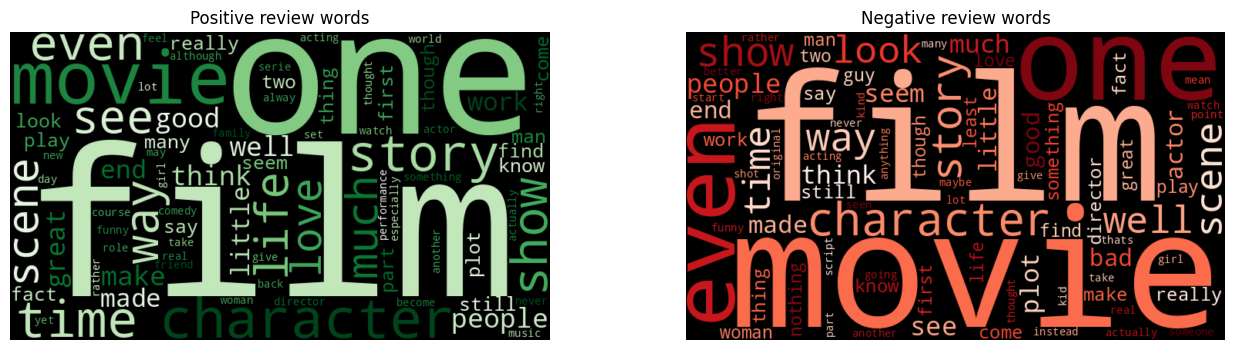

In [66]:
#Sorting clean reviews by positive and negative
pos_text = ' '.join(df[df['sentiment'] == 'positive']['clean_reviews'])
neg_text = ' '.join(df[df['sentiment'] == 'negative']['clean_reviews'])


fig, axes = plt.subplots(1,2, figsize=(16,4))

#Positive Word Cloud
WordCloud(width=700, height=400, colormap='Greens', max_words = 80).generate(pos_text).to_image()
#WordCloud = configures cloud, .generate = which words, .to_image() = converts to img
#.imshow()  = how to display image on figure
axes[0].imshow(
    WordCloud(width=700, height=400, colormap='Greens', max_words = 80).generate(pos_text),
    interpolation = 'bilinear')
#interpolation just makes the words look more smoother
axes[0].set_title("Positive review words")
axes[0].axis('off')

#Negative WordCloud
axes[1].imshow(
    WordCloud(width=700, height=400, colormap='Reds', max_words = 80).generate(neg_text),
    interpolation = 'bilinear')
axes[1].set_title("Negative review words")
axes[1].axis('off')

plt.show()



# **3.Feature Extraction**

(Count Vectorizer, Tfidf Vectorizer, Train / Split )

Converting text into -> numeric matrix



**METHOD 1: CountVectorizer**
---

Every Unique word becomes a column, each review gets a count for each word

**METHOD 2: TF-IDF (TfidfVectorizer)**
---

TF = Term Frequency: how often does this word appear in review?

IDF = Inverse Document Frequency: how rare is this word across all reviews

'film' appears everywhere -> high IDF vs 'masterpiece' is rare -> low IDF


Nessicary Libraries

---

In [70]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer #from sklearn for the two methods
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline



**MINI DEMO TO SHOW HOW IT WORKS**

**VECTORIZER**

In [71]:
mini_docs = [
    "great film loved every moment", # Review 1
    "terrible film waste of time", #Review 2
    "loved the great acting great story" #Reviw 3
]
cv_demos  = CountVectorizer()
#fit transform comes from CountVectorizer => learn words and convert to numeric maxtrix
matrix = cv_demos.fit_transform(mini_docs)

ex_df = pd.DataFrame(
    matrix.toarray(), # turns that numerical matrix into readable array
    columns = cv_demos.get_feature_names_out(), #pulls vocabulary from column names into list
    index = ['Review 1', 'Review 2', 'Review 3']
)

#Show the vectorize
print(ex_df)


          acting  every  film  great  loved  ...  story  terrible  the  time  waste
Review 1       0      1     1      1      1  ...      0         0    0     0      0
Review 2       0      0     1      0      0  ...      0         1    0     1      1
Review 3       1      0     0      2      1  ...      1         0    1     0      0

[3 rows x 12 columns]


**N GRAMS**

Instead of single words like ["not","good"] -> seperate features

It takes phrases as features so "not good" -> one features


# **4. Train Models**

(sklearn Pipelines w/ Naive. Bayes, Logistic Regression, linear svm)

Nessicary Libraries

---

#**5. Evaluate**

(Accuracy, precision, recall, F1, confusion maxtrix)

#**6. Interpret and Perdict**

(Top words per class from Regression. Perdict on a brand new text)